# Week 4: Machine Learning Model Development and Evaluation

## Fake Job Posting Detection

### Objective
Build a machine learning classification model to predict whether a job posting is genuine or fraudulent.

### Model
Logistic Regression

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

# STEP 2 — Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/cleaned_fake_job_postings.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6841, 19)


# STEP 4 — Check the dataset

In [ ]:
print(df.head())

   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841 entries, 0 to 6840
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               6841 non-null   int64  
 1   title                6841 non-null   object 
 2   location             6718 non-null   object 
 3   department           2520 non-null   object 
 4   salary_range         1079 non-null   object 
 5   company_profile      5324 non-null   object 
 6   description          6841 non-null   object 
 7   requirements         5906 non-null   object 
 8   benefits             4102 non-null   object 
 9   telecommuting        6841 non-null   int64  
 10  has_company_logo     6841 non-null   int64  
 11  has_questions        6841 non-null   int64  
 12  employment_type      5194 non-null   object 
 13  required_experience  4032 non-null   object 
 14  required_education   3719 non-null   object 
 15  industry             4779 non-null   o

In [ ]:
print(df.isnull().sum())

job_id                    0
title                     0
location                123
department             4321
salary_range           5762
company_profile        1517
description               0
requirements            935
benefits               2739
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        1647
required_experience    2809
required_education     3122
industry               2062
function               2559
fraudulent                1
description_length        0
dtype: int64


In [ ]:
print(df["fraudulent"].value_counts(dropna=False))

fraudulent
0.0    6525
1.0     315
NaN       1
Name: count, dtype: int64


# STEP 5 — Remove the missing target row

In [ ]:
df = df.dropna(subset=["fraudulent"]).copy()

print("Shape after removing missing target:", df.shape)

Shape after removing missing target: (6840, 19)


# STEP 6 — Make sure the target is integer

In [ ]:
df["fraudulent"] = df["fraudulent"].astype(int)

print(df["fraudulent"].value_counts())

fraudulent
0    6525
1     315
Name: count, dtype: int64


# STEP 7 — Create X and y

X = input features.

y = target.

In [ ]:
features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "description_length"
]

X = df[features]
y = df["fraudulent"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6840, 7)
y shape: (6840,)


# STEP 8 — Check feature types

In [ ]:
print(X.dtypes)

telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
description_length      int64
dtype: object


# STEP 9 — Separate numerical and categorical columns

In [ ]:
numeric_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "description_length"
]

categorical_features = [
    "employment_type",
    "required_experience",
    "required_education"
]

# STEP 10 — Create preprocessing pipelines

This is an important ML concept.

Numerical preprocessing

We'll fill missing numerical values with the median and scale the values.

Categorical preprocessing

We'll fill missing values with the most frequent category and use One-Hot Encoding.

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# STEP 11 — Combine preprocessing

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# STEP 12 — Split the dataset

We'll use:

80% training

20% testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5472
Testing samples: 1368


# STEP 13 — Create Logistic Regression model

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# STEP 14 — Create the complete ML pipeline

In [ ]:
clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

# STEP 15 — Train the model

In [ ]:
clf.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# STEP 16 — Make predictions

In [ ]:
y_pred = clf.predict(X_test)

print(y_pred[:20])

[1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1]


# STEP 17 — Get prediction probabilities

This is needed for ROC-AUC and ROC curve.

In [ ]:
y_prob = clf.predict_proba(X_test)[:, 1]

print(y_prob[:20])

[0.58825563 0.61560254 0.2818147  0.71164899 0.45485467 0.26331066
 0.14802644 0.20477292 0.91745845 0.20772202 0.11917332 0.32232884
 0.29464412 0.28275993 0.17474497 0.35490527 0.27992453 0.19513105
 0.65812501 0.76947345]


# STEP 18 — Calculate evaluation metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7449
Precision: 0.1176
Recall   : 0.6984
F1-Score : 0.2014
ROC-AUC  : 0.8206


# STEP 19 — Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.98      0.75      0.85      1305
  Fraudulent       0.12      0.70      0.20        63

    accuracy                           0.74      1368
   macro avg       0.55      0.72      0.52      1368
weighted avg       0.94      0.74      0.82      1368



# STEP 20 — Create a results table

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Accuracy,0.7449
1,Precision,0.1176
2,Recall,0.6984
3,F1-Score,0.2014
4,ROC-AUC,0.8206


# STEP 21 — Visualization 1: Confusion Matrix

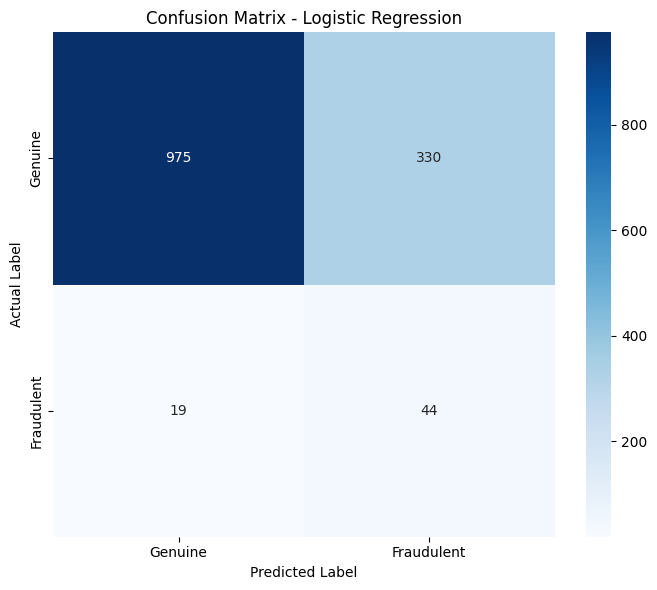

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraudulent"],
    yticklabels=["Genuine", "Fraudulent"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "week4_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# STEP 22 — Visualization 2: ROC Curve

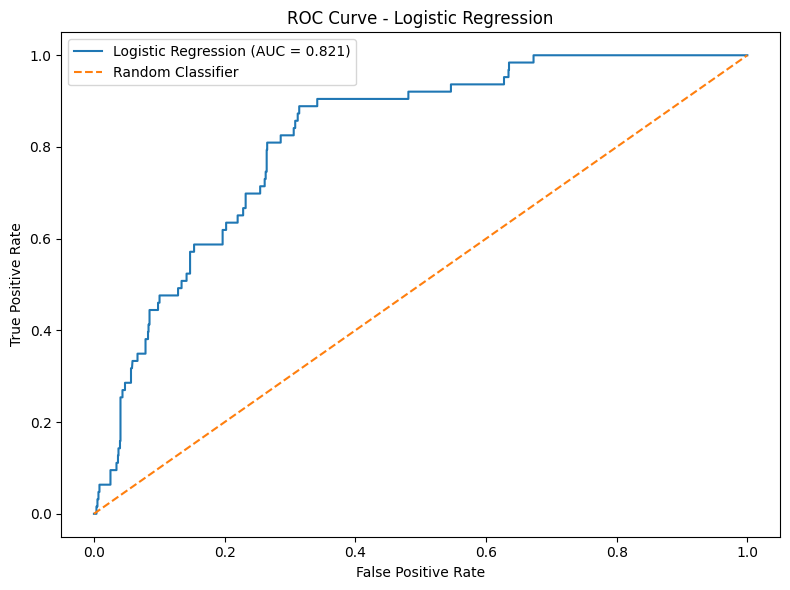

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()

plt.savefig(
    "week4_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# STEP 23 — Optional third visualization: Precision-Recall Curve

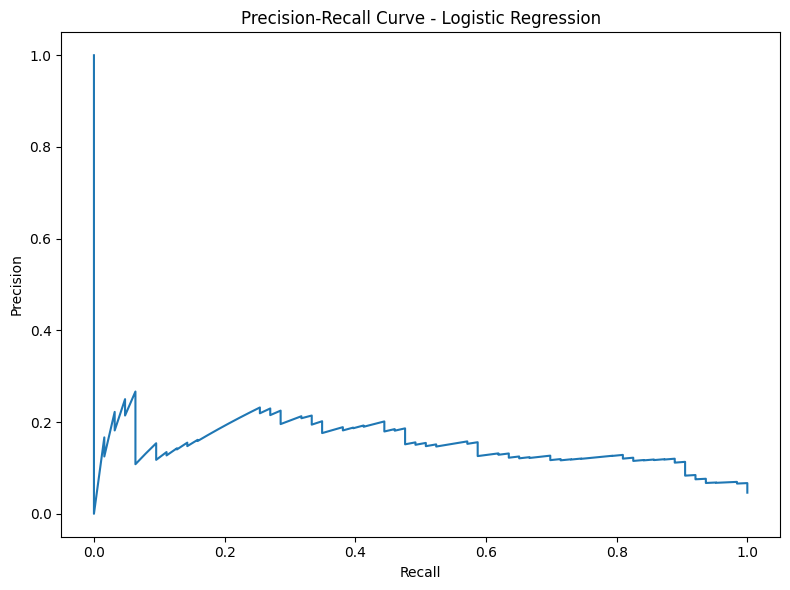

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()

plt.savefig(
    "week4_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# STEP 24 — Analyze model errors

In [ ]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred
error_analysis["Fraud_Probability"] = y_prob

error_analysis.head()

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,description_length,Actual,Predicted,Fraud_Probability
4652,0,1,1,Full-time,Entry level,High School or equivalent,668,0,1,0.588256
6463,0,1,1,Part-time,NaN,High School or equivalent,1445,0,1,0.615603
851,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,240,0,0,0.281815
4830,0,1,0,Full-time,Entry level,High School or equivalent,1443,0,1,0.711649
2225,0,1,1,Full-time,Associate,High School or equivalent,839,0,0,0.454855


Find false positives:

In [ ]:
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 330


Find false negatives:

In [ ]:
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 19
